# Heart Disease Classification — Modeling

## Objectives

In this notebook I train and evaluate two models on the processed data from `02_feature_engineering.ipynb`: Logistic Regression as a baseline and Random Forest for capturing non-linear relationships.

Logistic Regression is used as the baseline because it is interpretable and handles linear relationships between features and target well. If a simple linear model performs well, there is no need for added complexity. Random Forest is used to capture complex non-linear feature interactions that logistic regression cannot model — such as the `thalach`-`age` interaction identified in EDA.

## Output
A trained logistic regression and random forest model evaluated on accuracy, precision, recall, F1, and AUC-ROC. A confusion matrix and classification report are produced for each model, and a final comparison table summarizes performance across both models.

## 3.1 Setup & Imports

Importing the same core libraries as `01_eda.ipynb` with the addition of `sklearn` modules for modeling and evaluation. Path constants point to the processed data files from `02_feature_engineering.ipynb`. Random state is defined here to ensure reproducibility across all models.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore') # suppress outputs of warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
X_TRAIN_PATH = '../data/processed/X_train.csv'
X_TEST_PATH = '../data/processed/X_test.csv'
Y_TRAIN_PATH = '../data/processed/y_train.csv'
Y_TEST_PATH = '../data/processed/y_test.csv'

## 3.2 Load Processed Data

Loading the four processed datasets saved from `02_feature_engineering.ipynb` using the path constants defined in 3.1. `.squeeze()` is applied to `y_train` and `y_test` to convert them from single-column DataFrames to 1D Series, which is the format `sklearn` models expect for target variables.

In [2]:
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()


In [4]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


Shapes confirm the data loaded correctly. `X_train` has 242 rows and 13 features, `X_test` has 61 rows and 13 features, consistent with the 80/20 split from `02_feature_engineering.ipynb`. `y_train` and `y_test` are 1D arrays of 242 and 61 values respectively, confirming `.squeeze()` worked correctly.

## 3.3 Baseline Model — Logistic Regression

As the baseline model I implement Logistic Regression using `sklearn`'s `LogisticRegression`. Logistic regression is appropriate here because it models the 
linear relationship between features and the log-odds of the target, is highly interpretable, and serves as a strong baseline before introducing more complex models. The model is fit on `X_train` and `y_train`, then used to generate both class predictions (`predict`) and probability scores (`predict_proba`) for AUC-ROC evaluation.

In [ ]:
# create 
lr = LogisticRegression(random_state= RANDOM_STATE)
# fit
lr.fit(X_train, y_train)
# predict
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1] # for AUC-ROC evaluation

To evaluate performance I report precision, recall, F1-score, accuracy, and AUC-ROC. Since this is a medical classification problem, recall on class `1` is the most important metric — it measures how many actual disease cases the model correctly identified.

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

AUC-ROC score: 0.9234913793103449


Text(95.72222222222221, 0.5, 'Actual')

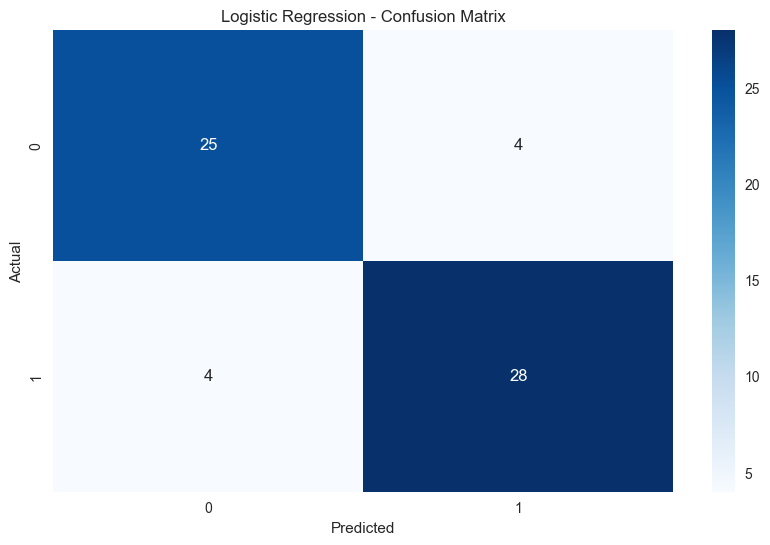

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_lr))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot = True, fmt = 'd', cmap= 'Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

The logistic regression baseline performs well. Precision, recall, and F1-score are consistent across both classes at 86-88%, with an overall accuracy of 87%. For a baseline model on a dataset of only 303 patients this is a strong result.

Recall for class `1` (disease present) is 0.88, meaning the model correctly identified 88% of actual disease cases and missed 4/32. While strong for a baseline, recall below 95% in a real clinical deployment would require threshold tuning to reduce false negatives — cases where a patient with disease is predicted as healthy, which in this context is the most costly error.

The AUC-ROC of 0.923 indicates excellent discriminating ability — there is a 92.3% chance the model ranks a random disease patient as higher risk than a random healthy patient.

Macro and weighted averages are both 0.87, consistent with the per-class metrics and reflect the roughly balanced class distribution of 29 no-disease and 32 disease cases in the test set.

The confusion matrix confirms 25 true negatives `(0,0)`, 4 false positives `(0,1)`, 4 false negatives `(1,0)`, and 28 true positives `(1,1)`. False negatives and false positives are equal at 4 each, but false negatives are the greater clinical concern, since misdiagnosing a patient as healthy when they have heart disease is potentially fatal. Future work would include threshold tuning to optimize recall for clinical deployment and error analysis on the 4 missed disease cases to identify any patterns in their feature values.

## 3.4 Random Forest

In addition to logistic regression, I implement Random Forest to capture non-linear relationships between features that logistic regression may have missed. The model is initialized with `n_estimators=100` — 100 trees balances performance and computational efficiency and is a standard starting point before hyperparameter tuning. `random_state=RANDOM_STATE` ensures reproducibility. Future work would include tuning `n_estimators` and `max_depth` to potentially improve performance.

In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

Same evaluation metrics as `3.3 Baseline Model — Logistic Regression` — precision, recall, F1-score, accuracy, and AUC-ROC — with recall on class `1` remaining the priority metric for this medical classification problem.

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

AUC-ROC score: 0.9391163793103448


Text(95.72222222222221, 0.5, 'Actual')

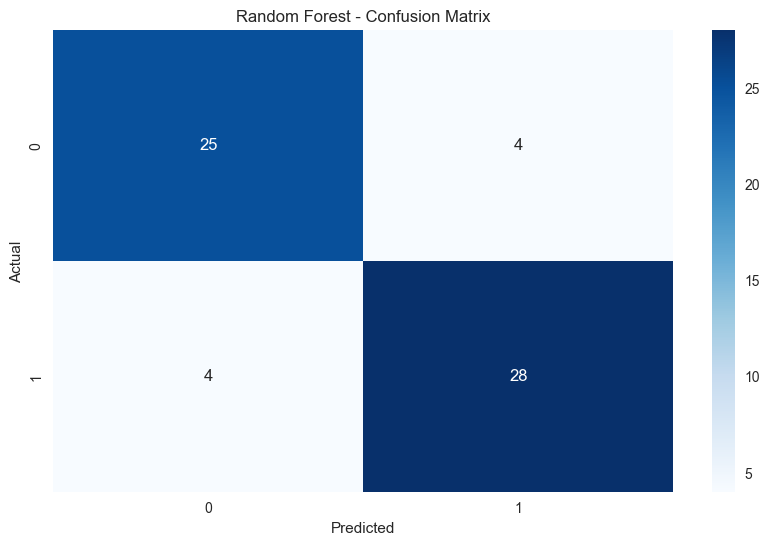

In [ ]:
# evaluation
print(classification_report(y_test, y_pred_rf))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot = True, fmt = 'd', cmap= 'Blues')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

Random forest produces identical classification metrics to logistic regression — 87% accuracy, 0.88 recall, 0.86-0.88 precision and F1 across both classes. The confusion matrix is also identical: 25 true negatives `(0,0)`, 4 false positives `(0,1)`, 4 false negatives `(1,0)`, and 28 true positives `(1,1)`.

The key difference between the models is the AUC-ROC — 0.939 vs 0.923 for logistic regression. Despite identical hard predictions, random forest assigns more confident probability scores to correct predictions, suggesting it is picking up some non-linear signal not captured by logistic regression. However, the identical confusion matrices suggest that the relationships in this dataset are largely linear and logistic regression accounts for most of the discriminating signal. Hyperparameter tuning may reveal further improvements in random forest performance.

## 3.5 Model Comparison

## 3.6 Conclusion